# LINEAR REGRESSION

In [69]:
from sklearn.datasets import load_diabetes #dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

In [70]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
X = df.drop("MEDV", axis=1)
y = df["MEDV"]


In [71]:
df.info() # kiểm tra kiểu dữ liệu
df.describe() #thống kê mô tả các biến dạng numerical trong data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [72]:
print(df.isnull().sum()) # kiểm tra dữ liệu null

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


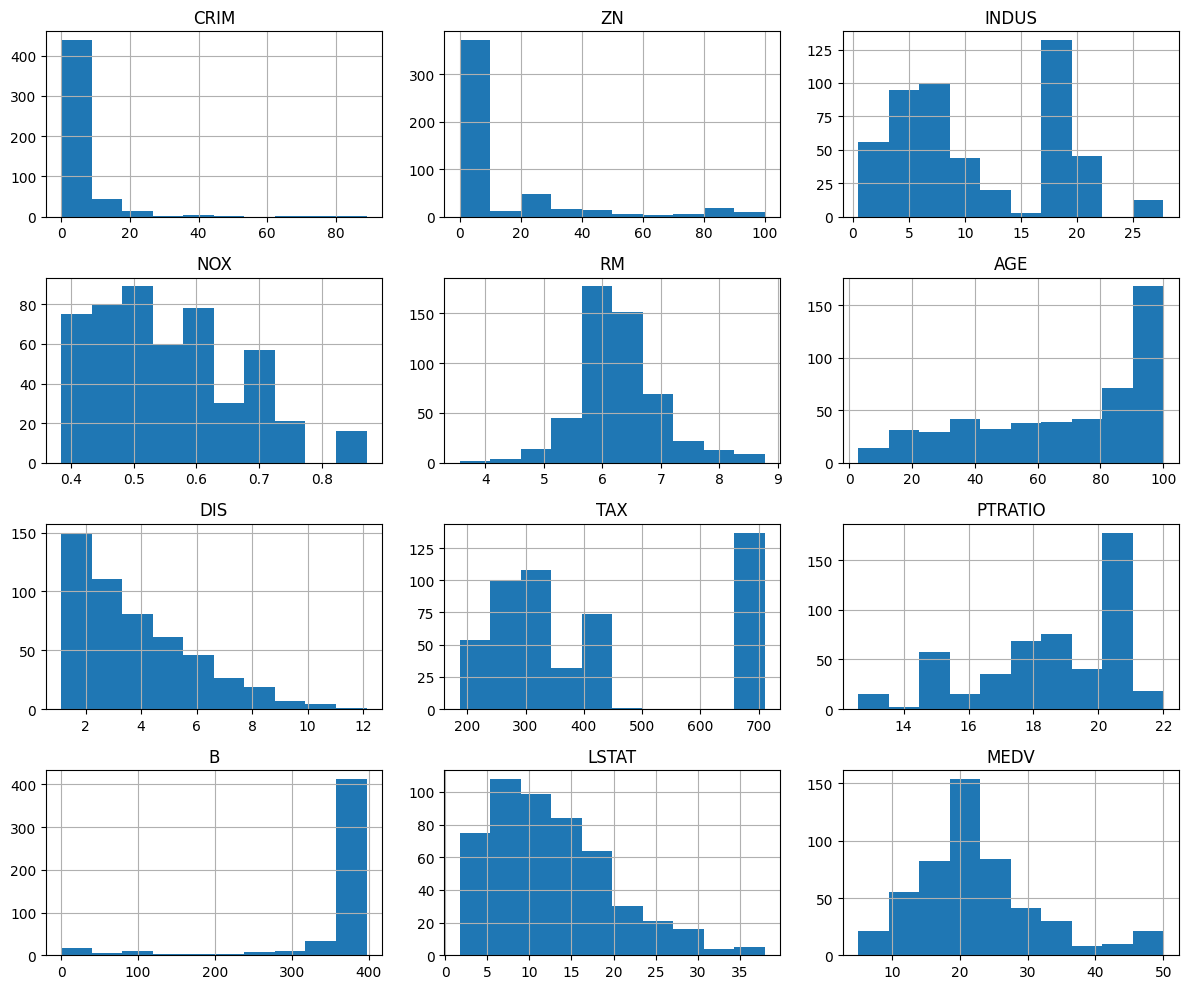

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
df.hist(bins=10, figsize=(12, 10))
plt.tight_layout()
plt.show()

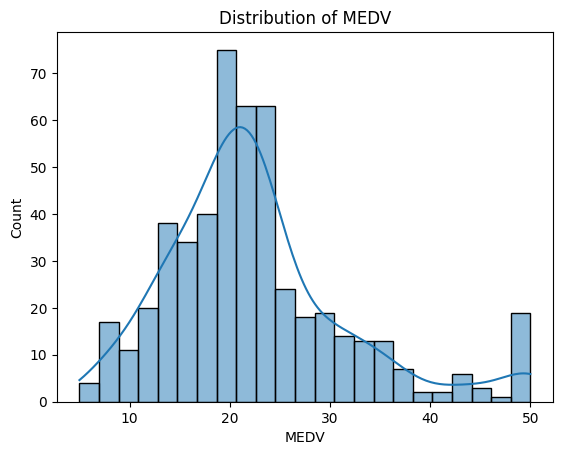

In [74]:
sns.histplot(df["MEDV"], kde=True)
plt.title("Distribution of MEDV")
plt.show()

In [75]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


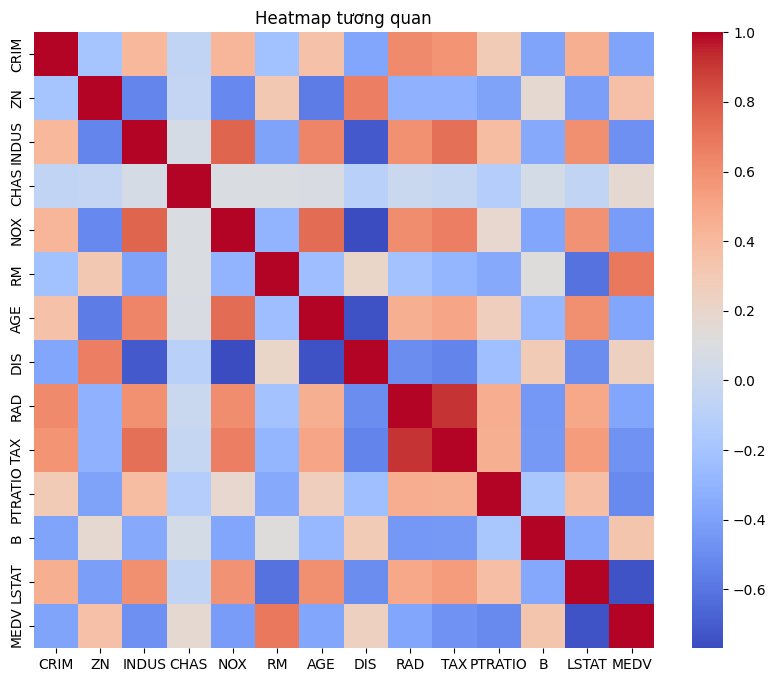

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Heatmap tương quan")
plt.show()

In [76]:
from sklearn.preprocessing import StandardScaler
X = df.drop("MEDV", axis=1)  # input features
y = df["MEDV"]               # target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(404, 13)
(404,)
(102, 13)
(102,)


In [78]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [79]:
print(model.intercept_)
print(model.coef_)

22.485268239316902
[-0.97149423  0.70155562  0.27675212  0.70653152 -1.99143043  3.11571836
 -0.17706021 -3.04577065  2.28278471 -1.79260468 -1.97995351  1.12649864
 -3.62814937]


In [56]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.6688
MAE: 3.1891
MSE: 24.2911
RMSE: 4.9286


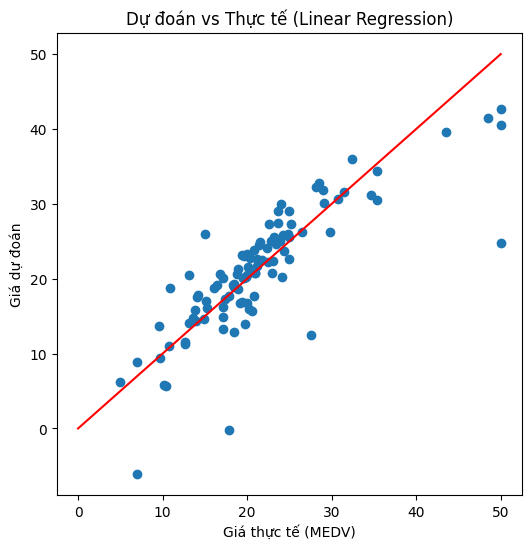

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Giá thực tế (MEDV)")
plt.ylabel("Giá dự đoán")
plt.title("Dự đoán vs Thực tế (Linear Regression)")
plt.plot([0, 50], [0, 50], color="red")  #  y=x
plt.show()

Xây dựng mô hình dự đoán "Performance index" của học sinh.

Link bộ dữ liệu: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression/data

Gợi ý: Với biến phân loại xử lý bằng encode

#LOGISITC REGRESSION

In [80]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="species") #['setosa' 'versicolor' 'virginica']
df = pd.concat([X, y], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [81]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [82]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [83]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


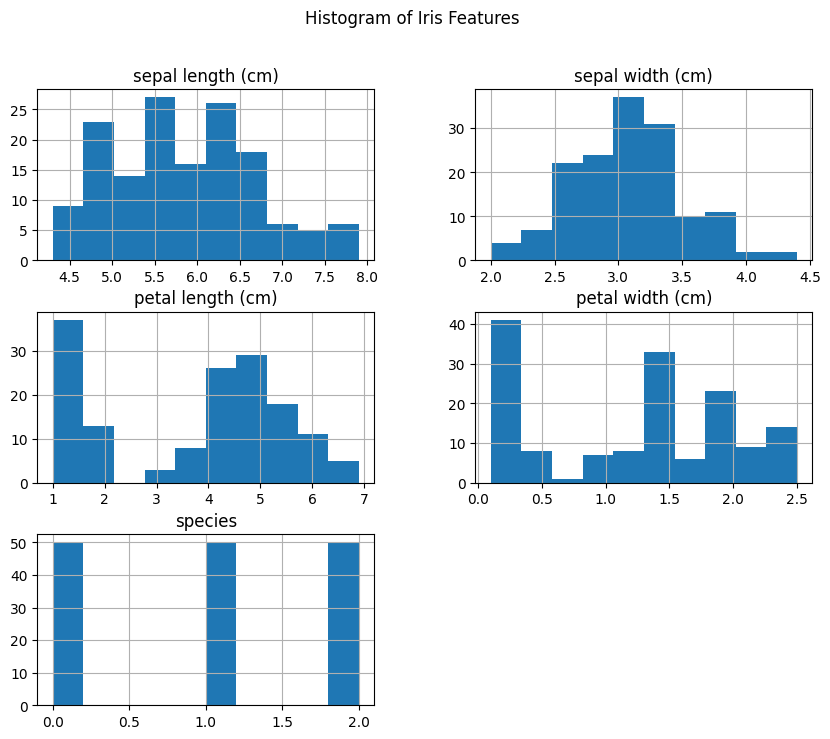

In [84]:
df.hist(figsize=(10, 8), bins=10)
plt.suptitle("Histogram of Iris Features")
plt.show()

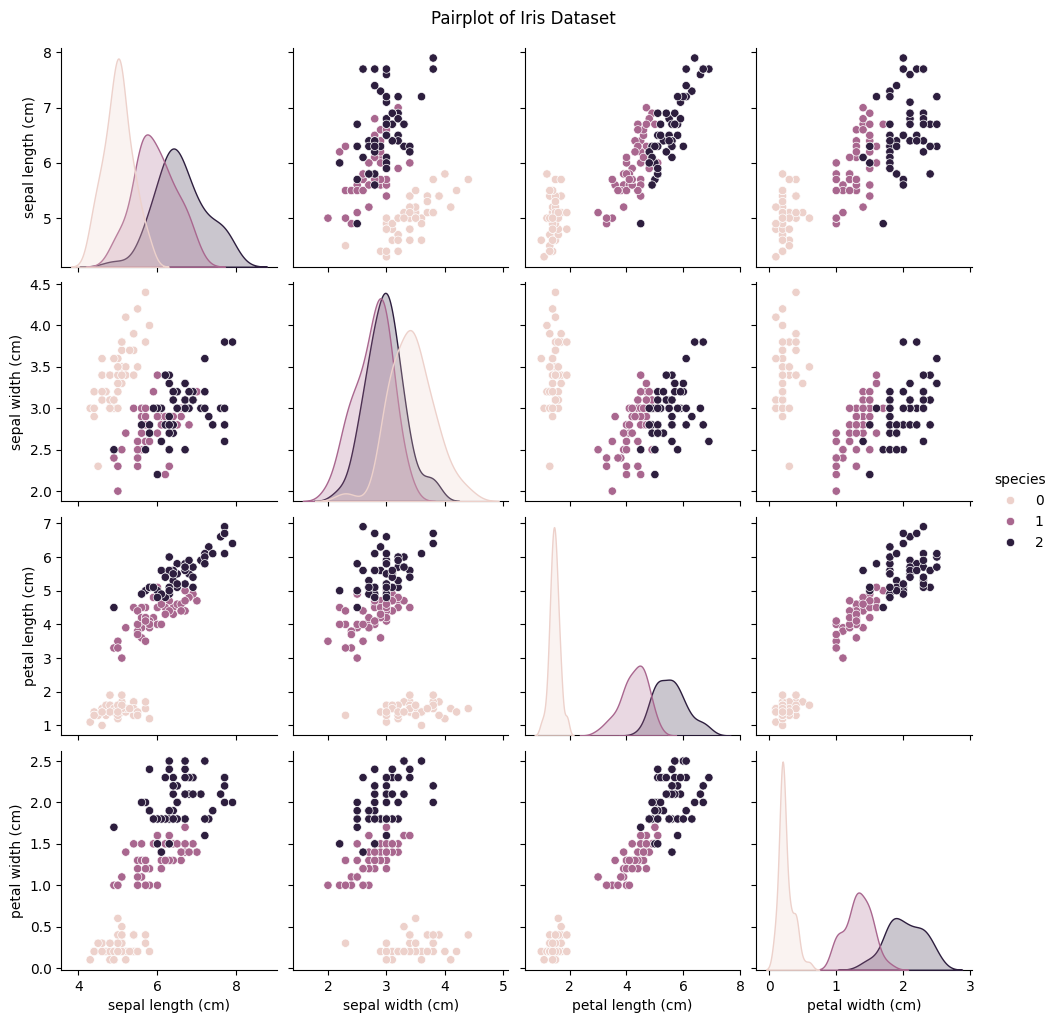

In [85]:
sns.pairplot(df, hue="species", diag_kind="kde")
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

Accuracy: 1.0


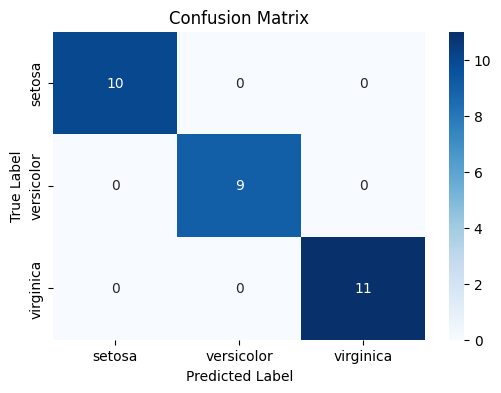

In [89]:
from sklearn.metrics import confusion_matrix

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [87]:
print(model.intercept_)
print(model.coef_)

[  9.00884295   1.86902164 -10.87786459]
[[-0.39345607  0.96251768 -2.37512436 -0.99874594]
 [ 0.50843279 -0.25482714 -0.21301129 -0.77574766]
 [-0.11497673 -0.70769055  2.58813565  1.7744936 ]]


Xây dựng mô hình logistic regression dự đoán kết quả học sinh pass/ fail.

Link bộ dữ liệu: https://www.kaggle.com/datasets/amrmaree/student-performance-prediction/data

Xử lý các biến phân loại bằng pd.get_dummies

## Student Performance Analysis - Predicting Pass/Fail

In [1]:
# Load and explore the student performance dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv("student_performance_dataset.csv")
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

In [ ]:
# Check value counts for categorical variables
print("Gender distribution:")
print(df['Gender'].value_counts())
print("\nParental Education Level:")
print(df['Parental_Education_Level'].value_counts())
print("\nInternet Access at Home:")
print(df['Internet_Access_at_Home'].value_counts())
print("\nExtracurricular Activities:")
print(df['Extracurricular_Activities'].value_counts())
print("\nPass/Fail distribution (Target Variable):")
print(df['Pass_Fail'].value_counts())

In [ ]:
# Visualize target variable distribution
plt.figure(figsize=(8, 5))
df['Pass_Fail'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Pass/Fail Distribution')
plt.xlabel('Pass/Fail')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Prepare features - drop Student_ID and target variable
# Use pd.get_dummies to encode categorical variables
df_encoded = df.drop(['Student_ID', 'Pass_Fail'], axis=1)

# Apply pd.get_dummies to categorical variables
df_encoded = pd.get_dummies(df_encoded, columns=['Gender', 'Parental_Education_Level', 
                                                   'Internet_Access_at_Home', 'Extracurricular_Activities'],
                             drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("\nColumn names after encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

In [ ]:
# Prepare X and y
X = df_encoded
y = df['Pass_Fail']

# Encode target variable: Pass = 1, Fail = 0
y = y.map({'Pass': 1, 'Fail': 0})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

In [ ]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Model coefficients shape:", model.coef_.shape)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")
print("\n" + "="*50)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Student Pass/Fail Prediction")
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted Fail): {cm[0, 0]}")
print(f"False Positives (Incorrectly predicted Pass): {cm[0, 1]}")
print(f"False Negatives (Incorrectly predicted Fail): {cm[1, 0]}")
print(f"True Positives (Correctly predicted Pass): {cm[1, 1]}")

In [ ]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)

print("Top 10 Most Positive Coefficients (Increase Pass probability):")
print(coefficients.head(10))
print("\n" + "="*50)
print("Top 10 Most Negative Coefficients (Decrease Pass probability):")
print(coefficients.tail(10))